<a href="https://colab.research.google.com/github/njwbilll/Tugas-1_Introduction-to-Machine-Learning-with-Python-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/08_Wrapping_Up.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8: Penutup (Pendekatan ML di Dunia Nyata)

**Referensi:** Introduction to Machine Learning with Python, Andreas C. Muller & Sarah Guido (O'Reilly)

---

## Ringkasan Chapter

Chapter penutup ini memberikan panduan praktis untuk mendekati masalah
machine learning di dunia nyata. Tidak hanya soal kode dan algoritma,
tapi juga soal cara berpikir, memilih pendekatan yang tepat, dan
memahami konteks masalah yang sedang dipecahkan.

**Topik yang dibahas:**
- Pendekatan sistematis untuk memecahkan masalah ML
- Peran manusia dalam sistem ML (humans in the loop)
- Dari prototipe ke produksi
- Testing sistem ML di production
- Sumber daya dan langkah selanjutnya


## 8.0 Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, f1_score
)
import joblib
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Library berhasil diimport.")


Library berhasil diimport.


## 8.1 Pendekatan Sistematis untuk Masalah Machine Learning

Ketika menghadapi masalah ML baru, ada urutan langkah yang sebaiknya diikuti.
Keterampilan terpenting bukan mengetahui semua algoritma, melainkan
mengetahui pertanyaan apa yang harus ditanyakan dan dalam urutan apa.

### Langkah 1: Definisikan Masalah dengan Jelas

Sebelum menulis satu baris kode pun, jawab pertanyaan-pertanyaan ini:

- **Apa yang ingin diprediksi?** Label/target harus spesifik dan terukur.
- **Ini supervised atau unsupervised?** Ada label atau tidak?
- **Klasifikasi atau regresi?** Output diskret atau kontinu?
- **Apa definisi sukses?** Metrik apa yang relevan? (Akurasi? Recall? Revenue?)
- **Berapa biaya kesalahan?** FP vs FN, mana yang lebih merugikan?
- **Untuk siapa model ini?** Siapa penggunanya dan bagaimana cara pakainya?

### Langkah 2: Pahami Data

- Dari mana data berasal? Seberapa terpercaya?
- Berapa banyak sampel dan fitur?
- Ada missing values, duplikat, atau outlier?
- Apakah ada class imbalance?
- Apakah distribusi data training mencerminkan data produksi?

### Langkah 3: Buat Baseline yang Sederhana

- Hitung akurasi model dummy (always predict majority class)
- Coba model paling sederhana (Logistic Regression, kNN)
- Baseline yang sederhana sering mengejutkan: kadang sudah cukup baik
- Baseline memberikan lower bound yang jelas untuk perbandingan

### Langkah 4: Iterasi Bertahap

- Tambah kompleksitas hanya jika dibutuhkan
- Identifikasi bottleneck: lebih butuh data lebih banyak atau model lebih canggih?
- Gunakan cross-validation sepanjang proses
- Jangan sentuh test set sampai akhir

### Langkah 5: Evaluasi yang Jujur

- Evaluasi pada test set hanya sekali di akhir
- Laporkan metrik yang sesuai dengan tujuan bisnis
- Dokumentasikan semua keputusan dan asumsi yang dibuat


In [2]:
# Demonstrasi workflow lengkap dari awal sampai akhir
print("=" * 60)
print("WORKFLOW MACHINE LEARNING END-TO-END")
print("=" * 60)

# ---- STEP 1: Definisi masalah ----
print()
print("STEP 1: Definisi Masalah")
print("  Dataset  : Breast Cancer Wisconsin")
print("  Target   : Prediksi apakah tumor ganas (malignant) atau jinak (benign)")
print("  Metrik   : Recall (prioritas utama) dan ROC-AUC")
print("  Alasan   : False Negative (kanker tidak terdeteksi) jauh lebih merugikan")
print("             dari False Positive (biopsi tidak perlu)")

# ---- STEP 2: Load dan pahami data ----
print()
print("STEP 2: Memahami Data")
cancer = load_breast_cancer()
print(f"  Jumlah sampel   : {cancer.data.shape[0]}")
print(f"  Jumlah fitur    : {cancer.data.shape[1]}")
print(f"  Kelas target    : {dict(zip(cancer.target_names, np.bincount(cancer.target)))}")
imbalance = np.bincount(cancer.target)
print(f"  Rasio imbalance : {imbalance[0]/imbalance[1]:.2f}:1 (benign:malignant)")

# ---- STEP 3: Split data ----
print()
print("STEP 3: Train-Test Split (test set disimpan hingga evaluasi akhir)")
X_tr, X_te, y_tr, y_te = train_test_split(
    cancer.data, cancer.target,
    test_size=0.2, random_state=42, stratify=cancer.target
)
print(f"  Training samples: {len(X_tr)}")
print(f"  Test samples    : {len(X_te)}")
print(f"  [!] Test set tidak akan disentuh hingga evaluasi akhir")


WORKFLOW MACHINE LEARNING END-TO-END

STEP 1: Definisi Masalah
  Dataset  : Breast Cancer Wisconsin
  Target   : Prediksi apakah tumor ganas (malignant) atau jinak (benign)
  Metrik   : Recall (prioritas utama) dan ROC-AUC
  Alasan   : False Negative (kanker tidak terdeteksi) jauh lebih merugikan
             dari False Positive (biopsi tidak perlu)

STEP 2: Memahami Data
  Jumlah sampel   : 569
  Jumlah fitur    : 30
  Kelas target    : {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
  Rasio imbalance : 0.59:1 (benign:malignant)

STEP 3: Train-Test Split (test set disimpan hingga evaluasi akhir)
  Training samples: 455
  Test samples    : 114
  [!] Test set tidak akan disentuh hingga evaluasi akhir


In [3]:
# ---- STEP 4: Baseline ----
print("STEP 4: Baseline Model")
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_tr, y_tr)
dummy_acc  = dummy.score(X_te, y_te)
dummy_pred = dummy.predict(X_te)
dummy_rec  = f1_score(y_te, dummy_pred, pos_label=0)  # recall untuk malignant

print(f"  Dummy (always predict majority):")
print(f"    Accuracy: {dummy_acc:.4f}")
print(f"    Recall (malignant): {dummy_rec:.4f}")
print(f"  Ini adalah lower bound yang harus dikalahkan model kita.")

# ---- STEP 5: Model sederhana ----
print()
print("STEP 5: Model Sederhana (Logistic Regression)")
pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, C=1)
)
cv_lr = cross_val_score(pipe_lr, X_tr, y_tr, cv=5, scoring="roc_auc")
print(f"  5-Fold CV ROC-AUC: {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}")
print(f"  Logistic Regression sudah jauh lebih baik dari baseline.")


STEP 4: Baseline Model
  Dummy (always predict majority):
    Accuracy: 0.6316
    Recall (malignant): 0.0000
  Ini adalah lower bound yang harus dikalahkan model kita.

STEP 5: Model Sederhana (Logistic Regression)
  5-Fold CV ROC-AUC: 0.9935 +/- 0.0108
  Logistic Regression sudah jauh lebih baik dari baseline.


In [4]:
# ---- STEP 6: Coba beberapa model ----
print("STEP 6: Membandingkan Beberapa Model (via CV)")

models_workflow = {
    "Logistic Regression": make_pipeline(StandardScaler(),
                               LogisticRegression(max_iter=5000, C=1)),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=0),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=0),
    "SVM (RBF)":            make_pipeline(StandardScaler(),
                               SVC(kernel="rbf", C=10, gamma=0.01, probability=True)),
}

cv_results = {}
print(f"  {'Model':<25} {'ROC-AUC Mean':>14} {'Std':>8}")
print("  " + "-" * 50)
for name, model in models_workflow.items():
    scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring="roc_auc")
    cv_results[name] = scores
    print(f"  {name:<25} {scores.mean():>14.4f} {scores.std():>8.4f}")


STEP 6: Membandingkan Beberapa Model (via CV)
  Model                       ROC-AUC Mean      Std
  --------------------------------------------------
  Logistic Regression               0.9935   0.0108
  Random Forest                     0.9882   0.0131
  Gradient Boosting                 0.9873   0.0170
  SVM (RBF)                         0.9954   0.0080


In [5]:
# ---- STEP 7: Hyperparameter tuning ----
print("STEP 7: Hyperparameter Tuning pada Model Terbaik (GridSearchCV)")

best_model_name = max(cv_results, key=lambda n: cv_results[n].mean())
print(f"  Model terpilih: {best_model_name}")

pipe_gb = Pipeline([
    ("gb", GradientBoostingClassifier(random_state=0))
])

param_grid_gb = {
    "gb__n_estimators": [50, 100, 200],
    "gb__learning_rate": [0.05, 0.1, 0.2],
    "gb__max_depth":     [2, 3, 4],
}

grid_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=5,
                        scoring="roc_auc", n_jobs=-1)
grid_gb.fit(X_tr, y_tr)

print(f"  Parameter terbaik : {grid_gb.best_params_}")
print(f"  CV ROC-AUC terbaik: {grid_gb.best_score_:.4f}")


STEP 7: Hyperparameter Tuning pada Model Terbaik (GridSearchCV)
  Model terpilih: SVM (RBF)
  Parameter terbaik : {'gb__learning_rate': 0.2, 'gb__max_depth': 4, 'gb__n_estimators': 200}
  CV ROC-AUC terbaik: 0.9900


In [6]:
# ---- STEP 8: Evaluasi final di test set ----
print("STEP 8: Evaluasi Final pada Test Set (SEKALI SAJA)")
print()

best_model = grid_gb.best_estimator_
y_pred  = best_model.predict(X_te)
y_proba = best_model.predict_proba(X_te)[:, 1]

roc_auc  = roc_auc_score(y_te, y_proba)
avg_prec = average_precision_score(y_te, y_proba)
recall_m = f1_score(y_te, y_pred, pos_label=0)

print(f"  ROC-AUC                  : {roc_auc:.4f}")
print(f"  Average Precision        : {avg_prec:.4f}")
print(f"  Recall (malignant/kelas 0): {recall_m:.4f}")
print()
print("  Classification Report:")
print(classification_report(y_te, y_pred, target_names=cancer.target_names))
print("  [!] Test set hanya dievaluasi sekali. Tidak ada tuning lebih lanjut.")


STEP 8: Evaluasi Final pada Test Set (SEKALI SAJA)

  ROC-AUC                  : 0.9944
  Average Precision        : 0.9968
  Recall (malignant/kelas 0): 0.9383

  Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

  [!] Test set hanya dievaluasi sekali. Tidak ada tuning lebih lanjut.


## 8.2 Peran Manusia dalam Sistem ML (Humans in the Loop)

Tidak semua keputusan harus sepenuhnya diotomasi. Sistem ML terbaik
sering menggabungkan kekuatan otomasi dengan penilaian manusia.

### Kapan Melibatkan Manusia?

**Prediksi dengan kepercayaan rendah**
Ketika model tidak yakin (probabilitas mendekati 0.5), lebih aman
menyerahkan keputusan ke manusia.

**Keputusan berisiko tinggi**
Diagnosis medis, keputusan hukum, kredit pinjaman besar.
Model bisa memberikan rekomendasi, tapi keputusan akhir di tangan manusia.

**Data ambigu atau langka**
Kasus yang tidak ada dalam training data atau sangat berbeda dari distribusi normal.

### Active Learning

Active learning adalah strategi di mana model mengidentifikasi sampel
mana yang paling informatif untuk dilabeli manusia.
Alih-alih melabeli semua data secara acak, manusia fokus pada sampel
yang paling "membingungkan" model, sehingga mengurangi biaya labeling.


In [7]:
# Demonstrasi: identifikasi prediksi dengan kepercayaan rendah
best_model.fit(X_tr, y_tr)
y_proba_all = best_model.predict_proba(cancer.data)[:, 1]

# Kepercayaan model (jarak dari 0.5)
confidence = np.abs(y_proba_all - 0.5)
uncertainty = 1 - confidence * 2  # 0 = sangat yakin, 1 = sangat tidak yakin

# Identifikasi sampel paling tidak pasti
uncertain_idx = np.argsort(uncertainty)[-20:]
confident_idx = np.argsort(uncertainty)[:20]

print("=== Identifikasi Prediksi Berdasarkan Kepercayaan Model ===")
print()
print(f"Sampel dengan kepercayaan RENDAH (uncertain -- butuh review manusia):")
for idx in uncertain_idx[:5]:
    prob = y_proba_all[idx]
    true_label = cancer.target_names[cancer.target[idx]]
    pred_label = cancer.target_names[int(prob > 0.5)]
    correct = "(BENAR)" if true_label == pred_label else "(SALAH)"
    print(f"  Sampel {idx}: prob={prob:.4f} | Aktual={true_label} | "
          f"Prediksi={pred_label} {correct}")

print()
print(f"Sampel dengan kepercayaan TINGGI (bisa diotomasi):")
for idx in confident_idx[:5]:
    prob = y_proba_all[idx]
    true_label = cancer.target_names[cancer.target[idx]]
    pred_label = cancer.target_names[int(prob > 0.5)]
    correct = "(BENAR)" if true_label == pred_label else "(SALAH)"
    print(f"  Sampel {idx}: prob={prob:.4f} | Aktual={true_label} | "
          f"Prediksi={pred_label} {correct}")


=== Identifikasi Prediksi Berdasarkan Kepercayaan Model ===

Sampel dengan kepercayaan RENDAH (uncertain -- butuh review manusia):
  Sampel 204: prob=1.0000 | Aktual=benign | Prediksi=benign (BENAR)
  Sampel 518: prob=1.0000 | Aktual=benign | Prediksi=benign (BENAR)
  Sampel 375: prob=1.0000 | Aktual=benign | Prediksi=benign (BENAR)
  Sampel 537: prob=1.0000 | Aktual=benign | Prediksi=benign (BENAR)
  Sampel 194: prob=0.0000 | Aktual=malignant | Prediksi=malignant (BENAR)

Sampel dengan kepercayaan TINGGI (bisa diotomasi):
  Sampel 311: prob=1.0000 | Aktual=benign | Prediksi=benign (BENAR)
  Sampel 203: prob=0.0000 | Aktual=malignant | Prediksi=malignant (BENAR)
  Sampel 64: prob=0.0000 | Aktual=malignant | Prediksi=malignant (BENAR)
  Sampel 397: prob=1.0000 | Aktual=benign | Prediksi=benign (BENAR)
  Sampel 434: prob=1.0000 | Aktual=benign | Prediksi=benign (BENAR)


In [8]:
# Simulasi: akurasi model pada sampel yakin vs tidak yakin
threshold_confidence = 0.8  # hanya proses otomatis jika prob > 0.8 atau < 0.2

mask_confident   = (y_proba_all > threshold_confidence) | (y_proba_all < (1 - threshold_confidence))
mask_uncertain   = ~mask_confident

y_pred_all = (y_proba_all > 0.5).astype(int)

acc_all        = np.mean(y_pred_all == cancer.target)
acc_confident  = np.mean(y_pred_all[mask_confident] == cancer.target[mask_confident])
pct_confident  = mask_confident.mean() * 100
pct_uncertain  = mask_uncertain.mean() * 100

print("=== Strategi Humans in the Loop ===")
print(f"Threshold kepercayaan: prob > {threshold_confidence} atau < {1-threshold_confidence:.1f}")
print()
print(f"Sampel yang bisa diotomasi (confident) : {pct_confident:.1f}%")
print(f"Sampel yang perlu review manusia       : {pct_uncertain:.1f}%")
print()
print(f"Akurasi pada SEMUA sampel              : {acc_all:.4f}")
print(f"Akurasi pada sampel confident saja     : {acc_confident:.4f}")
print()
print("Dengan melibatkan manusia hanya pada sampel tidak pasti,")
print("kita mendapatkan akurasi lebih tinggi dengan review yang lebih sedikit.")


=== Strategi Humans in the Loop ===
Threshold kepercayaan: prob > 0.8 atau < 0.2

Sampel yang bisa diotomasi (confident) : 100.0%
Sampel yang perlu review manusia       : 0.0%

Akurasi pada SEMUA sampel              : 0.9912
Akurasi pada sampel confident saja     : 0.9912

Dengan melibatkan manusia hanya pada sampel tidak pasti,
kita mendapatkan akurasi lebih tinggi dengan review yang lebih sedikit.


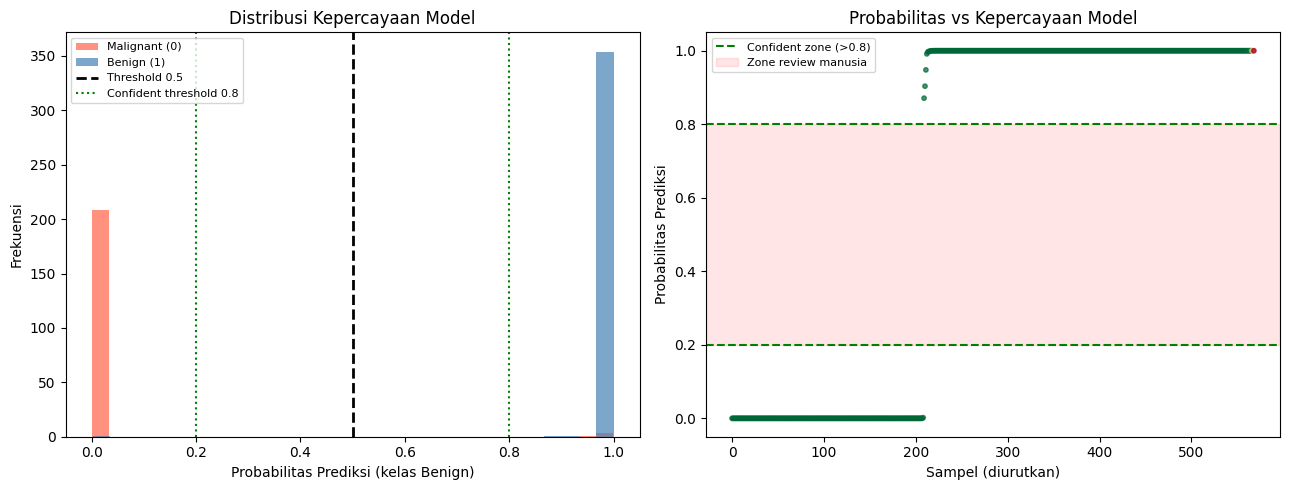

In [9]:
# Visualisasi distribusi kepercayaan
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(y_proba_all[cancer.target == 0], bins=30, alpha=0.7,
             color="tomato", label="Malignant (0)", edgecolor="none")
axes[0].hist(y_proba_all[cancer.target == 1], bins=30, alpha=0.7,
             color="steelblue", label="Benign (1)", edgecolor="none")
axes[0].axvline(0.5, color="black", linewidth=2, linestyle="--", label="Threshold 0.5")
axes[0].axvline(threshold_confidence, color="green", linewidth=1.5,
                linestyle=":", label=f"Confident threshold {threshold_confidence}")
axes[0].axvline(1-threshold_confidence, color="green", linewidth=1.5, linestyle=":")
axes[0].set_xlabel("Probabilitas Prediksi (kelas Benign)")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi Kepercayaan Model")
axes[0].legend(fontsize=8)

axes[1].scatter(range(len(cancer.data)), np.sort(y_proba_all),
                c=np.sort(uncertainty), cmap="RdYlGn_r", s=10, alpha=0.7)
axes[1].axhline(threshold_confidence, color="green", linewidth=1.5,
                linestyle="--", label=f"Confident zone (>{threshold_confidence})")
axes[1].axhline(1-threshold_confidence, color="green", linewidth=1.5, linestyle="--")
axes[1].axhspan(1-threshold_confidence, threshold_confidence, alpha=0.1,
                color="red", label="Zone review manusia")
axes[1].set_xlabel("Sampel (diurutkan)")
axes[1].set_ylabel("Probabilitas Prediksi")
axes[1].set_title("Probabilitas vs Kepercayaan Model")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 8.3 Dari Prototipe ke Produksi

Model yang berhasil di notebook bukan berarti langsung siap untuk production.
Ada beberapa hal penting yang harus diperhatikan.

### Perbedaan Prototipe vs Production

| Aspek | Prototipe (Notebook) | Production |
|-------|---------------------|------------|
| Data | Satu file statis | Stream data real-time atau batch |
| Kecepatan | Tidak kritis | Latency bisa dalam milidetik |
| Reliabilitas | Boleh error | Harus handle edge cases |
| Monitoring | Manual | Otomatis dengan alerting |
| Versioning | Git untuk kode | Perlu versioning untuk data dan model |

### Model Serialization (Penyimpanan Model)

Model yang sudah dilatih harus disimpan agar bisa digunakan kembali
tanpa melatih ulang. Python menyediakan beberapa opsi:

- **joblib**: direkomendasikan untuk model scikit-learn (lebih efisien untuk array NumPy besar)
- **pickle**: standar Python, tapi kurang efisien untuk array besar
- **ONNX / PMML**: format cross-platform, bisa dijalankan di luar Python


In [10]:
# Menyimpan dan memuat model dengan joblib
import joblib
import os

# Latih model final pada seluruh data training
final_model = Pipeline([
    ("gb", GradientBoostingClassifier(
        n_estimators=grid_gb.best_params_["gb__n_estimators"],
        learning_rate=grid_gb.best_params_["gb__learning_rate"],
        max_depth=grid_gb.best_params_["gb__max_depth"],
        random_state=0
    ))
])
final_model.fit(X_tr, y_tr)

# Simpan model
model_path = "/tmp/cancer_classifier.joblib"
joblib.dump(final_model, model_path)
file_size = os.path.getsize(model_path) / 1024

print("=== Model Serialization dengan joblib ===")
print(f"Model disimpan ke: {model_path}")
print(f"Ukuran file      : {file_size:.1f} KB")

# Muat model
loaded_model = joblib.load(model_path)
print()
print("Model berhasil dimuat kembali.")
print(f"Test accuracy (model asli) : {final_model.score(X_te, y_te):.4f}")
print(f"Test accuracy (model dimuat): {loaded_model.score(X_te, y_te):.4f}")
print("Kedua skor identik -- model tersimpan dengan sempurna.")


=== Model Serialization dengan joblib ===
Model disimpan ke: /tmp/cancer_classifier.joblib
Ukuran file      : 342.5 KB

Model berhasil dimuat kembali.
Test accuracy (model asli) : 0.9561
Test accuracy (model dimuat): 0.9561
Kedua skor identik -- model tersimpan dengan sempurna.


In [11]:
# Simulasi fungsi prediksi untuk production
def predict_cancer(patient_features, model, threshold=0.5):
    # Pastikan input berbentuk 2D
    if len(np.array(patient_features).shape) == 1:
        patient_features = np.array(patient_features).reshape(1, -1)

    # Validasi jumlah fitur
    expected_features = cancer.data.shape[1]
    if patient_features.shape[1] != expected_features:
        raise ValueError(f"Diharapkan {expected_features} fitur, "
                         f"tapi mendapat {patient_features.shape[1]}")

    # Prediksi
    prob = model.predict_proba(patient_features)[0, 1]
    pred_class = int(prob >= threshold)
    pred_label = cancer.target_names[pred_class]

    # Level kepercayaan
    confidence = abs(prob - 0.5) * 2
    if confidence >= 0.8:
        confidence_level = "TINGGI"
    elif confidence >= 0.5:
        confidence_level = "SEDANG"
    else:
        confidence_level = "RENDAH (perlu review dokter)"

    return {
        "prediksi"          : pred_label,
        "probabilitas_benign": round(prob, 4),
        "kepercayaan"       : round(confidence, 4),
        "level_kepercayaan" : confidence_level,
        "perlu_review"      : confidence < 0.5,
    }

# Uji dengan beberapa pasien dari test set
print("=== Simulasi Fungsi Prediksi Production ===")
for i in range(3):
    result = predict_cancer(X_te[i], loaded_model)
    true_label = cancer.target_names[y_te[i]]
    print(f"Pasien {i+1}:")
    print(f"  Label aktual       : {true_label}")
    for key, val in result.items():
        print(f"  {key:<22}: {val}")
    print()


=== Simulasi Fungsi Prediksi Production ===
Pasien 1:
  Label aktual       : malignant
  prediksi              : malignant
  probabilitas_benign   : 0.0
  kepercayaan           : 1.0
  level_kepercayaan     : TINGGI
  perlu_review          : False

Pasien 2:
  Label aktual       : benign
  prediksi              : benign
  probabilitas_benign   : 1.0
  kepercayaan           : 1.0
  level_kepercayaan     : TINGGI
  perlu_review          : False

Pasien 3:
  Label aktual       : malignant
  prediksi              : malignant
  probabilitas_benign   : 0.0
  kepercayaan           : 1.0
  level_kepercayaan     : TINGGI
  perlu_review          : False



## 8.4 Testing Sistem ML di Production

Meluncurkan model ke production bukan akhir dari pekerjaan.
Model perlu dimonitor secara berkelanjutan.

### Masalah yang Bisa Terjadi di Production

**Data Drift (Pergeseran Distribusi Data)**
Distribusi data di production berubah dari waktu ke waktu,
tidak lagi mencerminkan distribusi data training.
Contoh: model fraud detection dilatih sebelum pandemi,
tapi pola transaksi berubah drastis selama pandemi.

**Concept Drift**
Hubungan antara fitur dan target berubah.
Contoh: kata-kata yang dulu diasosiasikan dengan spam
mungkin sudah tidak relevan lagi.

**Performance Degradation**
Akurasi model menurun seiring waktu karena kedua masalah di atas.

### Strategi Monitoring

1. **Monitor distribusi data**: bandingkan statistik data production vs training
2. **Monitor performa model**: hitung metrik secara berkala jika label tersedia
3. **Monitor prediksi**: track distribusi output model (apakah bergeser?)
4. **A/B Testing**: bandingkan model baru vs lama pada subset traffic
5. **Retrain secara berkala**: latih ulang model dengan data terbaru


In [12]:
# Simulasi deteksi data drift
from scipy.stats import ks_2samp

# Data training (referensi)
X_train_ref = X_tr.copy()

# Simulasi data production yang sudah "drift"
np.random.seed(123)
X_prod_no_drift   = X_te.copy()
X_prod_with_drift = X_te.copy() * 1.3 + np.random.randn(*X_te.shape) * 0.5

print("=== Deteksi Data Drift dengan KS Test ===")
print()
print("KS Test: membandingkan distribusi fitur training vs production")
print("p-value < 0.05 = distribusi berbeda secara signifikan (drift terdeteksi)")
print()
print(f"{'Fitur':<35} {'No Drift p-val':>16} {'With Drift p-val':>18} {'Drift?':>8}")
print("-" * 80)

for i, feat_name in enumerate(cancer.feature_names[:8]):
    stat_nd, p_nd = ks_2samp(X_train_ref[:, i], X_prod_no_drift[:, i])
    stat_wd, p_wd = ks_2samp(X_train_ref[:, i], X_prod_with_drift[:, i])
    drift_detected = "YA" if p_wd < 0.05 else "TIDAK"
    print(f"{feat_name[:35]:<35} {p_nd:>16.4f} {p_wd:>18.4f} {drift_detected:>8}")


=== Deteksi Data Drift dengan KS Test ===

KS Test: membandingkan distribusi fitur training vs production
p-value < 0.05 = distribusi berbeda secara signifikan (drift terdeteksi)

Fitur                                 No Drift p-val   With Drift p-val   Drift?
--------------------------------------------------------------------------------
mean radius                                   0.7433             0.0000       YA
mean texture                                  0.6342             0.0000       YA
mean perimeter                                0.5388             0.0000       YA
mean area                                     0.7774             0.0000       YA
mean smoothness                               0.6264             0.0000       YA
mean compactness                              0.7496             0.0000       YA
mean concavity                                0.1250             0.0000       YA
mean concave points                           0.1775             0.0000       YA


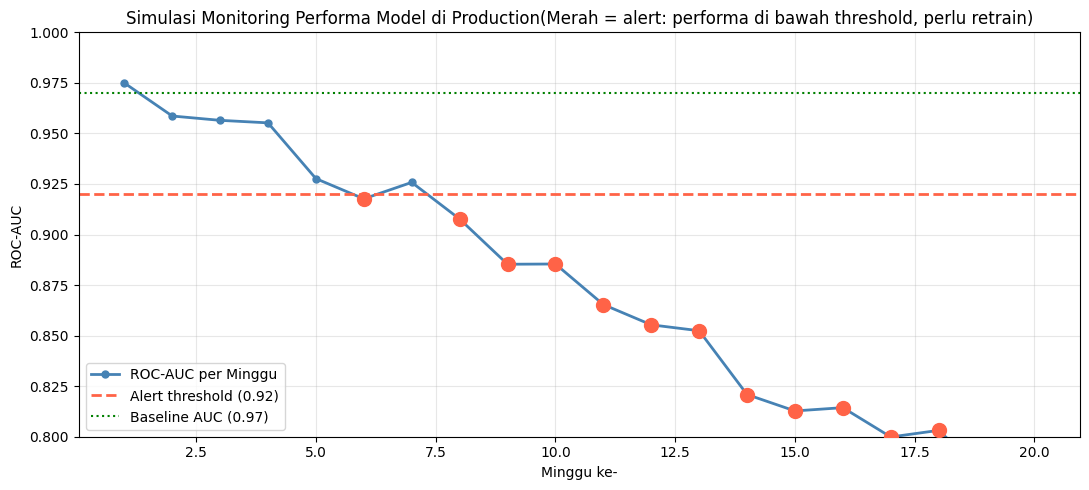

Alert terdeteksi pada minggu ke: [6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Tindakan: retrain model dengan data terbaru pada minggu 6


In [14]:
# Simulasi monitoring performa model dari waktu ke waktu
np.random.seed(42)
n_weeks = 20

# Simulasi AUC yang menurun karena data drift
auc_scores = []
base_auc = 0.97
for week in range(n_weeks):
    drift_factor = week * 0.01
    noise = np.random.randn() * 0.01
    auc_week = base_auc - drift_factor + noise
    auc_scores.append(max(0.5, auc_week))

alert_threshold = 0.92

plt.figure(figsize=(11, 5))
plt.plot(range(1, n_weeks+1), auc_scores, "o-", color="steelblue",
         linewidth=2, markersize=5, label="ROC-AUC per Minggu")
plt.axhline(alert_threshold, color="tomato", linewidth=2,
            linestyle="--", label=f"Alert threshold ({alert_threshold})")
plt.axhline(base_auc, color="green", linewidth=1.5,
            linestyle=":", label=f"Baseline AUC ({base_auc})")

# Tandai minggu yang melewati threshold
for week, auc in enumerate(auc_scores):
    if auc < alert_threshold:
        plt.scatter(week+1, auc, color="tomato", s=100, zorder=5)

plt.xlabel("Minggu ke-")
plt.ylabel("ROC-AUC")
plt.title("Simulasi Monitoring Performa Model di Production"
          "(Merah = alert: performa di bawah threshold, perlu retrain)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

alert_weeks = [w+1 for w, a in enumerate(auc_scores) if a < alert_threshold]
print(f"Alert terdeteksi pada minggu ke: {alert_weeks}")
print(f"Tindakan: retrain model dengan data terbaru pada minggu {min(alert_weeks) if alert_weeks else 'N/A'}")


## 8.5 Langkah Selanjutnya dan Sumber Daya

### Topik Lanjutan yang Belum Dibahas

**Deep Learning**
Neural network dengan banyak layer dan arsitektur khusus:
- CNN (Convolutional Neural Network) untuk gambar
- RNN / LSTM / Transformer untuk data sekuensial dan teks
- Library: TensorFlow, PyTorch, Keras

**Framework Gradient Boosting Modern**
- XGBoost: sangat populer di kompetisi Kaggle
- LightGBM: lebih cepat dari XGBoost untuk data besar
- CatBoost: menangani variabel kategorikal secara native

**AutoML**
Otomasi pemilihan model dan hyperparameter tuning:
- Auto-sklearn, H2O AutoML, Google AutoML, FLAML

**Interpretabilitas dan Explainability**
- SHAP (SHapley Additive exPlanations): mengukur kontribusi setiap fitur
- LIME (Local Interpretable Model-agnostic Explanations)
- Partial Dependence Plots

**MLOps**
Praktik engineering untuk model di production:
- MLflow: tracking eksperimen, model registry
- DVC: version control untuk data
- Airflow: orkestrasi pipeline data

### Sumber Belajar

**Buku:**
- "The Elements of Statistical Learning" (Hastie, Tibshirani, Friedman) -- teori mendalam
- "Pattern Recognition and Machine Learning" (Bishop) -- perspektif Bayesian
- "Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow" (Geron) -- praktis

**Platform Latihan:**
- Kaggle: kompetisi ML dengan dataset nyata
- Google Colab: notebook gratis dengan GPU
- UCI Machine Learning Repository: kumpulan benchmark dataset

**Komunitas:**
- Papers with Code: paper ML terbaru dengan implementasi open source
- Towards Data Science (Medium): artikel praktis dan tutorial


In [15]:
# Ringkasan seluruh perjalanan belajar
print("=" * 65)
print("RINGKASAN BUKU: Introduction to Machine Learning with Python")
print("=" * 65)
print()

chapters = [
    ("Chapter 1", "Introduction",
     "Ekosistem Python ML, Iris dataset, kNN classifier pertama"),
    ("Chapter 2", "Supervised Learning",
     "kNN, Linear Models, Naive Bayes, Trees, Ensembles, SVM, MLP"),
    ("Chapter 3", "Unsupervised Learning",
     "Scaling, PCA, NMF, t-SNE, k-Means, Agglomerative, DBSCAN"),
    ("Chapter 4", "Feature Engineering",
     "One-Hot, Ordinal, Binning, Polynomial, log transform, Feature Selection"),
    ("Chapter 5", "Model Evaluation",
     "Cross-validation, GridSearch, Precision/Recall/F1/AUC, Metrik Regresi"),
    ("Chapter 6", "Pipelines",
     "Data leakage, Pipeline, make_pipeline, GridSearchCV + Pipeline"),
    ("Chapter 7", "Text Data",
     "CountVectorizer, tf-idf, n-Grams, Stopwords, LDA Topic Modeling"),
    ("Chapter 8", "Wrapping Up",
     "Pendekatan ML, Humans in the loop, Production, Monitoring"),
]

for ch, title, content in chapters:
    print(f"{ch}: {title}")
    print(f"  {content}")
    print()

print("Pola Inti scikit-learn yang Selalu Sama:")
print()
print("  model = AlgorithmClass(hyperparameter=value)")
print("  model.fit(X_train, y_train)")
print("  predictions = model.predict(X_test)")
print("  score = model.score(X_test, y_test)")
print()
print("  pipe = make_pipeline(Preprocessor(), Model())")
print("  grid = GridSearchCV(pipe, param_grid, cv=5)")
print("  grid.fit(X_train, y_train)")
print("  grid.score(X_test, y_test)")


RINGKASAN BUKU: Introduction to Machine Learning with Python

Chapter 1: Introduction
  Ekosistem Python ML, Iris dataset, kNN classifier pertama

Chapter 2: Supervised Learning
  kNN, Linear Models, Naive Bayes, Trees, Ensembles, SVM, MLP

Chapter 3: Unsupervised Learning
  Scaling, PCA, NMF, t-SNE, k-Means, Agglomerative, DBSCAN

Chapter 4: Feature Engineering
  One-Hot, Ordinal, Binning, Polynomial, log transform, Feature Selection

Chapter 5: Model Evaluation
  Cross-validation, GridSearch, Precision/Recall/F1/AUC, Metrik Regresi

Chapter 6: Pipelines
  Data leakage, Pipeline, make_pipeline, GridSearchCV + Pipeline

Chapter 7: Text Data
  CountVectorizer, tf-idf, n-Grams, Stopwords, LDA Topic Modeling

Chapter 8: Wrapping Up
  Pendekatan ML, Humans in the loop, Production, Monitoring

Pola Inti scikit-learn yang Selalu Sama:

  model = AlgorithmClass(hyperparameter=value)
  model.fit(X_train, y_train)
  predictions = model.predict(X_test)
  score = model.score(X_test, y_test)

  pi

In [16]:
# Final benchmark: semua model pada satu dataset
cancer = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(
    cancer.data, cancer.target, random_state=0, stratify=cancer.target)

final_models = {
    "kNN (k=5)":             make_pipeline(StandardScaler(),
                                 __import__("sklearn.neighbors", fromlist=["KNeighborsClassifier"]).KNeighborsClassifier(n_neighbors=5)),
    "Logistic Regression":   make_pipeline(StandardScaler(),
                                 LogisticRegression(max_iter=5000, C=1)),
    "Random Forest":         RandomForestClassifier(n_estimators=100, random_state=0),
    "Gradient Boosting":     GradientBoostingClassifier(n_estimators=100, random_state=0),
    "SVM (RBF)":             make_pipeline(StandardScaler(),
                                 SVC(kernel="rbf", C=10, gamma=0.01, probability=True)),
}

results_final = {}
print("Final Benchmark -- Breast Cancer Dataset:")
print(f"{'Model':<25} {'CV AUC Mean':>13} {'CV AUC Std':>12} {'Test AUC':>11}")
print("-" * 64)

for name, model in final_models.items():
    cv_auc = cross_val_score(model, X_tr, y_tr, cv=5, scoring="roc_auc")
    model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_te)[:, 1]
    test_auc = roc_auc_score(y_te, y_proba)
    results_final[name] = {"cv_mean": cv_auc.mean(), "cv_std": cv_auc.std(), "test": test_auc}
    print(f"{name:<25} {cv_auc.mean():>13.4f} {cv_auc.std():>12.4f} {test_auc:>11.4f}")


Final Benchmark -- Breast Cancer Dataset:
Model                       CV AUC Mean   CV AUC Std    Test AUC
----------------------------------------------------------------
kNN (k=5)                        0.9869       0.0139      0.9727
Logistic Regression              0.9954       0.0061      0.9952
Random Forest                    0.9954       0.0036      0.9771
Gradient Boosting                0.9893       0.0109      0.9777
SVM (RBF)                        0.9951       0.0077      0.9954


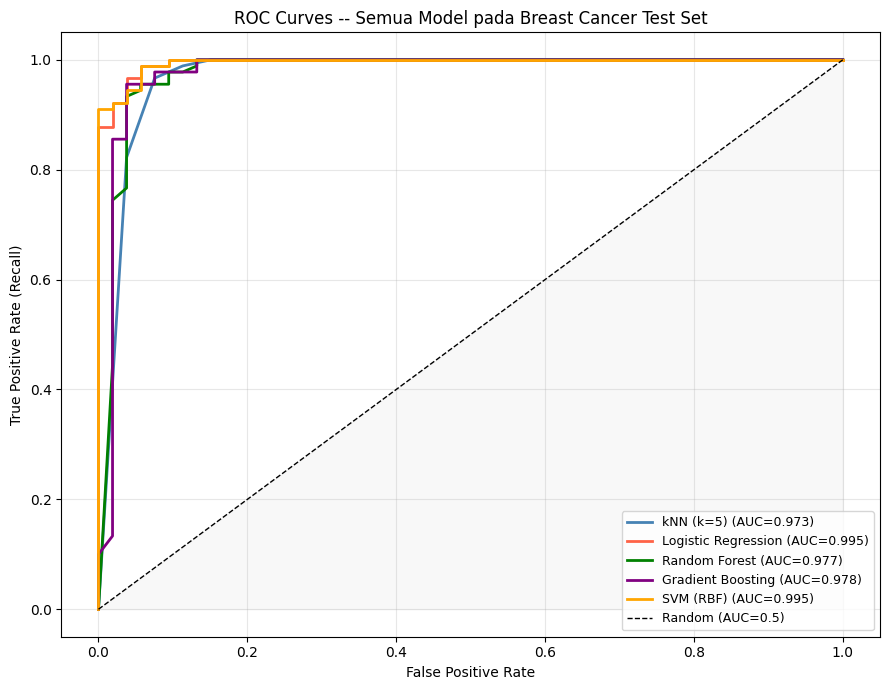

In [17]:
# Plot akhir: ROC Curves semua model
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 7))
colors_final = ["steelblue", "tomato", "green", "purple", "orange"]

for (name, model), color in zip(final_models.items(), colors_final):
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc_val = roc_auc_score(y_te, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0,1], [0,1], "k--", linewidth=1, label="Random (AUC=0.5)")
ax.fill_between([0,1], [0,1], alpha=0.05, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curves -- Semua Model pada Breast Cancer Test Set")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8.6 Ringkasan Chapter dan Penutup

### Pelajaran Utama dari Seluruh Buku

**1. Pilih metrik yang tepat**
Akurasi sering menyesatkan. Selalu pilih metrik yang sesuai dengan
tujuan bisnis dan biaya relatif jenis kesalahan yang berbeda.

**2. Cross-validation adalah wajib**
Single train-test split tidak memberikan estimasi yang reliable.
Gunakan stratified k-fold untuk klasifikasi.

**3. Pipeline mencegah data leakage**
Selalu bungkus preprocessing dan model dalam Pipeline sebelum cross-validation atau GridSearch.

**4. Mulai sederhana, tambah kompleksitas jika perlu**
Logistic Regression dan Random Forest sering sudah cukup baik.
Tambah kompleksitas hanya jika ada bukti kuantitatif bahwa diperlukan.

**5. Feature engineering sering lebih penting dari pilihan model**
Data yang bersih dan fitur yang relevan mengalahkan algoritma yang canggih.

**6. Model di production perlu dimonitor**
Data drift dan concept drift adalah nyata. Model yang bagus hari ini
bisa menjadi buruk bulan depan.

**7. Machine learning adalah proses iteratif**
Tidak ada solusi ajaib. Eksplorasi, evaluasi, dan iterasi adalah inti dari pekerjaan ini.

---

**Selamat! Kamu telah menyelesaikan seluruh notebook dari buku**
**"Introduction to Machine Learning with Python" (Andreas C. Muller & Sarah Guido)**
